In [17]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.3 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.2 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 0.8/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.6/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.8/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 2.1/101.7 MB 1.2 MB/s eta 0:01:23
    --------------------------------------- 2.4/101.7 MB 1.2 MB/s eta 0:01:23
   - -------------------------------------- 2.6/101.7 MB 1.2 MB/s eta 0:01:23
   - -------------------------------------- 2.9/101.7 MB 1.2 MB/s eta 0:01:22
   - -------------------------------------- 3.1/101.7 MB 1.2 MB/s eta 0:01:22



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.metrics import precision_recall_curve

In [30]:
train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test = pd.read_csv('../6.Data/Yann_Process_test.csv')

target = 'target_is_fraud'
id_col = 'customer_id'

selected_features = [
    'chargebacks_12m',
    'failed_payments_6m',
    'device_trust_z',
    'ip_risk_z',
    'is_vpn',
    'is_new_device',
    'partner_risk_indicator',
    'num_devices_30d',
    'days_since_last_login',
    'support_tickets_90d',
    'internal_signal_1',
    'internal_signal_2',
    'internal_signal_3',
]

X = train[selected_features]
y = train[target]
X_test = test[selected_features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
}

scorer = make_scorer(f1_score, pos_label=1)

grid = GridSearchCV(model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print('Best params:', grid.best_params_)

# Optimisation du seuil
y_proba = best_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]
print(f"Meilleur seuil : {best_threshold:.3f}")

y_pred = (y_proba >= best_threshold).astype(int)

print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))
print('\nClassification Report:')
print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Meilleur seuil : 0.752

Confusion Matrix:
[[27379  1866]
 [ 1463  1292]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     29245
           1       0.41      0.47      0.44      2755

    accuracy                           0.90     32000
   macro avg       0.68      0.70      0.69     32000
weighted avg       0.90      0.90      0.90     32000



In [31]:
# Prédiction binaire 0/1 pour Kaggle
X_test_sel = X_test[selected_features]

test_predictions = best_model.predict(X_test_sel)

submission = pd.DataFrame({
"customer_id": test["customer_id"], "target_is_fraud": test_predictions
})

submission.to_csv('../7.Submission/submission_rf_simple.csv', index=False)
print('Submission exportée.')

Submission exportée.


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.metrics import make_scorer, average_precision_score
import pandas as pd
import numpy as np

train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test = pd.read_csv('../6.Data/Yann_Process_test.csv')

target = 'target_is_fraud'
id_col = 'customer_id'

selected_features = [
    'chargebacks_12m', 'failed_payments_6m', 'device_trust_z', 'ip_risk_z',
    'is_vpn', 'is_new_device', 'partner_risk_indicator', 'legacy_partner_score',
    'max_to_avg_ratio', 'num_devices_30d', 'days_since_last_login',
    'support_tickets_90d', 'internal_signal_1', 'internal_signal_2',
    'internal_signal_3', 'internal_signal_4', 'internal_signal_5',
    'internal_signal_6', 'internal_signal_7', 'internal_signal_8',
    'age', 'tenure_months', 'credit_score', 'annual_income_eur',
    'num_transactions_30d', 'avg_amount_30d_eur', 'max_amount_30d_eur',
]

selected_features = [f for f in selected_features if f in train.columns]

X = train[selected_features]
y = train[target]
X_test = test[selected_features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 5],
    'gamma': [0, 0.1],
}

scorer = make_scorer(average_precision_score, needs_proba=True)

# RandomizedSearchCV : 30 combinaisons au lieu de 972 → ~15-20 minutes
grid = RandomizedSearchCV(
    model, param_grid,
    n_iter=30,          # ← clé : seulement 30 tirages aléatoires
    cv=3,               # ← 3 folds au lieu de 5
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f"Best params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")

y_proba = best_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold_f1 = thresholds[f1_scores[:-1].argmax()]

target_recall = 0.60
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
best_threshold_recall = thresholds[valid_idx[np.argmax(precisions[valid_idx])]] if len(valid_idx) > 0 else best_threshold_f1

for label, threshold in [("Seuil F1", best_threshold_f1), ("Seuil Recall 0.60", best_threshold_recall)]:
    print(f"\n{'='*50}")
    print(f"  {label} ({threshold:.3f})")
    print('='*50)
    y_pred = (y_proba >= threshold).astype(int)
    print(confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred))

importances = pd.Series(best_model.feature_importances_, index=selected_features)
print("\nTop 10 features :")
print(importances.sort_values(ascending=False).head(10))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


c:\Users\natha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV score: nan

  Seuil F1 (0.752)
[[27230  2015]
 [ 1389  1366]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     29245
           1       0.40      0.50      0.45      2755

    accuracy                           0.89     32000
   macro avg       0.68      0.71      0.69     32000
weighted avg       0.90      0.89      0.90     32000


  Seuil Recall 0.60 (0.671)
[[26003  3242]
 [ 1101  1654]]
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     29245
           1       0.34      0.60      0.43      2755

    accuracy                           0.86     32000
   macro avg       0.65      0.74      0.68     32000
weighted avg       0.91      0.86      0.88     32000


Top 10 features :
ip_risk_z             0.215288
is_new_device  

In [36]:
for target_recall in [0.55, 0.60, 0.65, 0.70]:
    valid_idx = np.where(recalls[:-1] >= target_recall)[0]
    if len(valid_idx) > 0:
        threshold = thresholds[valid_idx[np.argmax(precisions[valid_idx])]]
        y_pred = (y_proba >= threshold).astype(int)
        print(f"\nRecall cible >= {target_recall} | Seuil : {threshold:.3f}")
        print(confusion_matrix(y_val, y_pred))
        print(classification_report(y_val, y_pred))


Recall cible >= 0.55 | Seuil : 0.711
[[26629  2616]
 [ 1235  1520]]
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     29245
           1       0.37      0.55      0.44      2755

    accuracy                           0.88     32000
   macro avg       0.66      0.73      0.69     32000
weighted avg       0.91      0.88      0.89     32000


Recall cible >= 0.6 | Seuil : 0.671
[[26003  3242]
 [ 1101  1654]]
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     29245
           1       0.34      0.60      0.43      2755

    accuracy                           0.86     32000
   macro avg       0.65      0.74      0.68     32000
weighted avg       0.91      0.86      0.88     32000


Recall cible >= 0.65 | Seuil : 0.629
[[25284  3961]
 [  964  1791]]
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     29245
           1       0.31      0.

In [39]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'min_child_samples': [10, 20],
}

grid = RandomizedSearchCV(
    model, param_grid,
    n_iter=20,
    cv=3,
    scoring=scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\natha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


,estimator,"LGBMClassifie...), verbose=-1)"
,param_distributions,"{'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'min_child_samples': [10, 20], 'n_estimators': [200, 300], ...}"
,n_iter,20
,scoring,make_scorer(a...ds_proba=True)
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [40]:
y_proba = best_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

for target_recall in [0.55, 0.60, 0.65, 0.70]:
    valid_idx = np.where(recalls[:-1] >= target_recall)[0]
    if len(valid_idx) > 0:
        threshold = thresholds[valid_idx[np.argmax(precisions[valid_idx])]]
        y_pred = (y_proba >= threshold).astype(int)
        print(f"\n{'='*50}")
        print(f"  Recall cible >= {target_recall} | Seuil : {threshold:.3f}")
        print('='*50)
        print(confusion_matrix(y_val, y_pred))
        print(classification_report(y_val, y_pred))


  Recall cible >= 0.55 | Seuil : 0.711
[[26629  2616]
 [ 1235  1520]]
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     29245
           1       0.37      0.55      0.44      2755

    accuracy                           0.88     32000
   macro avg       0.66      0.73      0.69     32000
weighted avg       0.91      0.88      0.89     32000


  Recall cible >= 0.6 | Seuil : 0.671
[[26003  3242]
 [ 1101  1654]]
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     29245
           1       0.34      0.60      0.43      2755

    accuracy                           0.86     32000
   macro avg       0.65      0.74      0.68     32000
weighted avg       0.91      0.86      0.88     32000


  Recall cible >= 0.65 | Seuil : 0.629
[[25284  3961]
 [  964  1791]]
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     29245
           1       0.31  

In [33]:
# Juste relancer l'évaluation avec différents seuils, sans réentraîner
for target_recall in [0.40, 0.50, 0.60, 0.70]:
    valid_idx = np.where(recalls[:-1] >= target_recall)[0]
    if len(valid_idx) > 0:
        threshold = thresholds[valid_idx[np.argmax(precisions[valid_idx])]]
        y_pred = (y_proba >= threshold).astype(int)
        print(f"\n{'='*50}")
        print(f"  Recall cible >= {target_recall} | Seuil : {threshold:.3f}")
        print('='*50)
        print(confusion_matrix(y_val, y_pred))
        print(classification_report(y_val, y_pred))
    else:
        print(f"\n⚠️ Recall >= {target_recall} non atteignable")


  Recall cible >= 0.4 | Seuil : 0.805
[[27959  1286]
 [ 1648  1107]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     29245
           1       0.46      0.40      0.43      2755

    accuracy                           0.91     32000
   macro avg       0.70      0.68      0.69     32000
weighted avg       0.90      0.91      0.91     32000


  Recall cible >= 0.5 | Seuil : 0.747
[[27156  2089]
 [ 1377  1378]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     29245
           1       0.40      0.50      0.44      2755

    accuracy                           0.89     32000
   macro avg       0.67      0.71      0.69     32000
weighted avg       0.90      0.89      0.90     32000


  Recall cible >= 0.6 | Seuil : 0.671
[[26003  3242]
 [ 1101  1654]]
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     29245
           1       0.34    

In [35]:
X_test_sel = X_test[selected_features]

test_predictions = best_model.predict(X_test_sel)

submission = pd.DataFrame({
"customer_id": test["customer_id"], "target_is_fraud": test_predictions
})

submission.to_csv('../7.Submission/submission_rf_simple_2.csv', index=False)
print('Submission exportée.')

Submission exportée.


In [10]:
train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test = pd.read_csv('../6.Data/Yann_Process_test.csv')

target = 'target_is_fraud'
id_col = 'customer_id'

selected_features = [
    'chargebacks_12m',
    'failed_payments_6m',
    'device_trust_z',
    'ip_risk_z',
    'is_vpn',
    'is_new_device',
    'partner_risk_indicator',
    'legacy_partner_score',
    'max_to_avg_ratio',
    'num_devices_30d',
    'days_since_last_login',
    'support_tickets_90d',
    'internal_signal_1',
    'internal_signal_2',
    'internal_signal_3',
]

X = train[selected_features]  # ✅ sélection appliquée
y = train[target]
X_test = test[selected_features]  # ✅ sélection appliquée

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

rf = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_resampled, y_resampled)

best_model = grid.best_estimator_
print('Best params:', grid.best_params_)

y_pred = best_model.predict(X_val)
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred))
print('\nClassification Report:')
print(classification_report(y_val, y_pred))

Best params: {'n_estimators': 300}
Confusion Matrix:
[[26145  4870]
 [  703   282]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     31015
           1       0.05      0.29      0.09       985

    accuracy                           0.83     32000
   macro avg       0.51      0.56      0.50     32000
weighted avg       0.95      0.83      0.88     32000



In [4]:
train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test = pd.read_csv('../6.Data/Yann_Process_test.csv')

target = 'target_is_fraud'
id_col = 'customer_id'

selected_features = [
    'chargebacks_12m',
    'failed_payments_6m',
    'device_trust_z',
    'ip_risk_z',
    'is_vpn',
    'is_new_device',
    'partner_risk_indicator',
    'legacy_partner_score',
    'max_to_avg_ratio',
    'num_devices_30d',
    'days_since_last_login',
    'support_tickets_90d',
    'internal_signal_1',
    'internal_signal_2',
    'internal_signal_3',
]

X = train[selected_features]
y = train[target]
X_test = test[selected_features]

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

Train shape: (160000, 15)
Test shape: (40000, 15)


In [5]:


target = 'target_is_fraud'
id_col = 'customer_id'

X = train.drop(columns=[target, id_col])
y = train[target]
X_test = test.drop(columns=[id_col])

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


In [8]:
rf = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
   
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_resampled, y_resampled)


best_model = grid.best_estimator_
print('Best params:', grid.best_params_)


Best params: {'n_estimators': 300}


In [9]:
y_pred = best_model.predict(X_val)

print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred))

print('\nClassification Report:')
print(classification_report(y_val, y_pred))


Confusion Matrix:
[[30698   317]
 [  942    43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     31015
           1       0.12      0.04      0.06       985

    accuracy                           0.96     32000
   macro avg       0.54      0.52      0.52     32000
weighted avg       0.94      0.96      0.95     32000



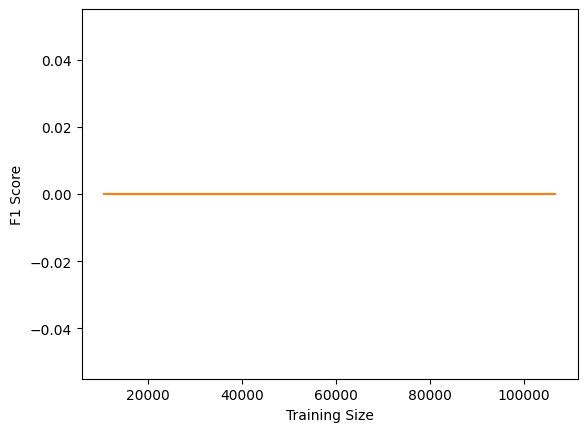

In [15]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=3, scoring='f1', n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1))
plt.plot(train_sizes, val_scores.mean(axis=1))
plt.xlabel('Training Size')
plt.ylabel('F1 Score')
plt.show()

In [ ]:
# Prédiction binaire 0/1 pour Kaggle
test_predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    "customer_id": test_df["customer_id"],
    "target_is_fraud": test_predictions
})

submission.to_csv('../submissions/submission_rf_simple.csv', index=False)
print('Submission exportée.')


In [ ]:
test_df = pd.read_csv('../data/test.csv')